In [1]:
import os
import pandas as pd
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
from datetime import datetime
import glob
from netCDF4 import Dataset
import sys
sys.path.insert(1, '/glade/work/ihtam/wrf-stuff/analysis/')
from util.wrf_process import (calc_derive, object_tracking, read_and_write)
from util.ml_preprocess import data_preproc
import gc
from tqdm import tqdm
import xarray as xr
import sys
import pickle
from natsort import natsorted
import proplot as plot
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Nimbus Roman', 'Times', 'C059-Roman', 'P052-Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

/glade/derecho/scratch/ihtam/tmp/ipykernel_22593/127406129.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 15.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 12.5,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})


/glade/derecho/scratch/ihtam/tmp/ipykernel_22593/2808163545.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


## Read in data and find TC center location

In [5]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
aiaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

## Calculate axisymmetry

In [4]:
def _get_dx_dy_km(ds: xr.Dataset):
    """Return (dx_km, dy_km) from WRF attrs if present; else rough estimate from lat/lon."""
    if "DX" in ds.attrs and "DY" in ds.attrs:
        return float(ds.attrs["DX"]) / 1000.0, float(ds.attrs["DY"]) / 1000.0
    # Fallback: estimate from lat/lon near domain center
    lat = ds["XLAT"].isel(Time=0) if "Time" in ds["XLAT"].dims else ds["XLAT"]
    lon = ds["XLONG"].isel(Time=0) if "Time" in ds["XLONG"].dims else ds["XLONG"]
    j, i = np.array(lat.shape) // 2
    R = 6371.0
    dlat = np.deg2rad(float(lat[j+1, i] - lat[j, i]))
    dlon = np.deg2rad(float(lon[j, i+1] - lon[j, i]))
    dx = R * dlon * np.cos(np.deg2rad(float(lat[j, i])))
    dy = R * dlat
    return abs(dx), abs(dy)

def _bin_moments(field2d, labels, nb):
    """Ring means m1 and mean of squares m2 using bincount; ignores labels==-1 and NaNs."""
    f = field2d.ravel()
    lab = labels.ravel()
    good = (lab >= 0) & np.isfinite(f)
    f = f[good]; lab = lab[good]
    if f.size == 0:
        return np.full(nb, np.nan), np.full(nb, np.nan)
    sum1 = np.bincount(lab, weights=f, minlength=nb).astype(float)
    sum2 = np.bincount(lab, weights=f*f, minlength=nb).astype(float)
    cnt  = np.bincount(lab, minlength=nb).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        m1 = sum1 / cnt
        m2 = sum2 / cnt
    m1[cnt==0] = np.nan; m2[cnt==0] = np.nan
    return m1, m2


def axisymmetry_2d_single(field2d, j_c, i_c, dx_km, dy_km, rmax_km=300.0, dr_km=3.0):
    """
    Compute γ(r) and mean γ̄ from a single 2D field (Eq. 17 & 18 without z).

    Parameters
    ----------
    field2d : 2D numpy array (y, x)
        The field (e.g., max reflectivity).
    j_c, i_c : int
        Storm center indices (y, x).
    dx_km, dy_km : float
        Grid spacing in km.
    rmax_km : float
        Max radius to include (km).
    dr_km : float
        Ring width (km).

    Returns
    -------
    gamma_r : 1D array of γ(r) per radial bin
    r_centers : 1D array of bin center radii (km)
    gamma_bar : float, system-wide axisymmetry
    """

    ny, nx = field2d.shape
    yy, xx = np.meshgrid(np.arange(ny) - j_c, np.arange(nx) - i_c, indexing="ij")
    r_km = np.sqrt((yy * dy_km) ** 2 + (xx * dx_km) ** 2)

    # define radial bins
    nb = int(np.floor(rmax_km / dr_km))
    edges = np.arange(0, (nb+1)*dr_km, dr_km)
    r_centers = (edges[:-1] + edges[1:]) / 2.0
    rbin = np.digitize(r_km, edges) - 1
    rbin[(rbin < 0) | (rbin >= nb)] = -1

    # flatten and mask
    f = field2d.values.ravel()
    lab = rbin.ravel()
    good = (lab >= 0) & np.isfinite(f)
    f, lab = f[good], lab[good]

    # compute azimuthal mean and mean-square
    sum1 = np.bincount(lab, weights=f, minlength=nb).astype(float)
    sum2 = np.bincount(lab, weights=f*f, minlength=nb).astype(float)
    cnt  = np.bincount(lab, minlength=nb).astype(float)
    m1 = np.full(nb, np.nan); m2 = np.full(nb, np.nan)
    m1[cnt>0] = sum1[cnt>0]/cnt[cnt>0]
    m2[cnt>0] = sum2[cnt>0]/cnt[cnt>0]

    # γ(r) = m1^2 / m2
    gamma_r = (m1*m1)/m2
    gamma_bar = np.nanmean(gamma_r)

    return gamma_r, r_centers, gamma_bar

def calc_asym(ncfile,ix,iy,dx=3,dy=3,rmax_km=400.0):
    mdbz = getvar(ncfile,'mdbz')
    return axisymmetry_2d_single(mdbz, int(iy.data), int(ix.data), dx, dy, rmax_km=rmax_km)[2]

In [5]:
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
aiaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

ctrl_axi,miaxi2x_axi,mdd_p2f_axi = [],[],[]
dd_p2f_axi,aiaxi2x_axi= [],[]
for i in tqdm(range(len(ctrl_files))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    nc_miaxi2x = Dataset(miaxi2x_files[i])
    nc_aiaxi2x = Dataset(aiaxi2x_files[i])
    nc_mdd_p2f2x = Dataset(mdd_p2f_files[i])
    nc_dd_p2f2x = Dataset(dd_p2f_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Read in max reflectivity
    ctrl_mdbz = getvar(nc_ctrl,'mdbz')
    dd_p2f_mdbz = getvar(nc_dd_p2f2x,'mdbz')
    mdd_p2f_mdbz = getvar(nc_mdd_p2f2x,'mdbz')
    miaxi2x_mdbz = getvar(nc_miaxi2x,'mdbz')
    aiaxi2x_mdbz = getvar(nc_aiaxi2x,'mdbz')
    # Derive axisymmetry
    ctrl_axi.append(axisymmetry_2d_single(ctrl_mdbz, int(iy.data), int(ix.data), 3,3, rmax_km=200.0)[2])
    dd_p2f_axi.append(axisymmetry_2d_single(dd_p2f_mdbz, int(iy.data), int(ix.data), 3,3, rmax_km=200.0)[2])
    mdd_p2f_axi.append(axisymmetry_2d_single(mdd_p2f_mdbz, int(iy.data), int(ix.data), 3,3, rmax_km=200.0)[2])
    miaxi2x_axi.append(axisymmetry_2d_single(miaxi2x_mdbz, int(iy.data), int(ix.data), 3,3, rmax_km=200.0)[2])
    aiaxi2x_axi.append(axisymmetry_2d_single(aiaxi2x_mdbz, int(iy.data), int(ix.data), 3,3, rmax_km=200.0)[2])

100%|██████████| 29/29 [16:22<00:00, 33.88s/it]


In [6]:
axidict = {'ctrl':ctrl_axi,'miaxi2x':miaxi2x_axi,'mdd_p2f':mdd_p2f_axi,'dd_p2f':dd_p2f_axi,'aiaxi2x':aiaxi2x_axi}
with open(f"./store/haiyansen_axi.pkl", "wb") as f:
    pickle.dump(axidict, f)

In [9]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 15.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 12.5,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_89049/1606955898.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


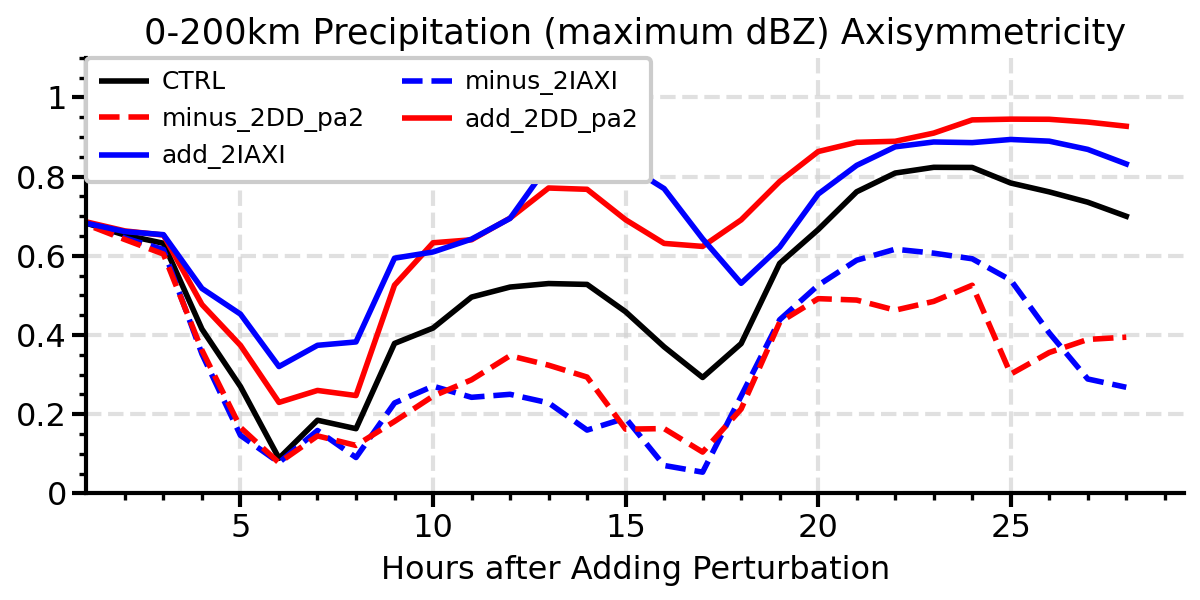

In [8]:
# ProPlot handles subplots with simple syntax
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(ctrl_axi,c='k',label='CTRL',lw=2)
axs.plot(miaxi2x_axi,c='b',ls='--',label='minus_2IAXI',lw=2)
axs.plot(mdd_p2f_axi,c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(dd_p2f_axi,c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(aiaxi2x_axi,c='b',ls='-',label='add_2IAXI',lw=2)
axs.format(xlim=(1,29.5),ylim=(0,1.1),
           title='0-200km Precipitation (maximum dBZ) Axisymmetricity',
           xlabel='Hours after Adding Perturbation', ylabel='')
plt.legend(loc=2,ncols=2)
plt.savefig('./pics/precipaxim_memb3.png',dpi=400)
plt.show()

## Vorticity development

In [6]:
ra = 100 #radius (Nam et al. 2023)
varname = 'pvo'
ctrl_avos,miaxi2x_avos,dd_p2f_avos,aiaxi2x_avos,mdd_p2f_avos = [],[],[],[],[]
for i in tqdm(range(len(ctrl_files))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    nc_miaxi2x = Dataset(miaxi2x_files[i])
    nc_dd_p2f2x = Dataset(dd_p2f_files[i])
    nc_mdd_p2f2x = Dataset(mdd_p2f_files[i])
    nc_aiaxi2x = Dataset(aiaxi2x_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Read in AVOR
    ctrl_avo = getvar(nc_ctrl,varname)
    dd_p2f_avo = getvar(nc_dd_p2f2x,varname)
    mdd_p2f_avo = getvar(nc_mdd_p2f2x,varname)
    miaxi2x_avo = getvar(nc_miaxi2x,varname)
    aiaxi2x_avo = getvar(nc_aiaxi2x,varname)
    # Read in Height
    ctrl_z = getvar(nc_ctrl,'height_agl')
    dd_p2f_z = getvar(nc_dd_p2f2x,'height_agl')
    mdd_p2f_z = getvar(nc_mdd_p2f2x,'height_agl')
    miaxi2x_z = getvar(nc_miaxi2x,'height_agl')
    aiaxi2x_z = getvar(nc_aiaxi2x,'height_agl')
    # Interpolate geopt to Height level
    ctrl_ht_6 = interplevel(ctrl_avo, ctrl_z, 6000)
    dd_p2f_ht_6 = interplevel(dd_p2f_avo, dd_p2f_z, 6000)
    mdd_p2f_ht_6 = interplevel(mdd_p2f_avo, mdd_p2f_z, 6000)
    miaxi2x_ht_6 = interplevel(miaxi2x_avo, miaxi2x_z, 6000)
    aiaxi2x_ht_6 = interplevel(aiaxi2x_avo, aiaxi2x_z, 6000)
    
    ctrl_ht_1 = interplevel(ctrl_avo, ctrl_z, 1000)
    dd_p2f_ht_1 = interplevel(dd_p2f_avo, dd_p2f_z, 1000)
    mdd_p2f_ht_1 = interplevel(mdd_p2f_avo, mdd_p2f_z, 1000)
    miaxi2x_ht_1 = interplevel(miaxi2x_avo, miaxi2x_z, 1000)
    aiaxi2x_ht_1 = interplevel(aiaxi2x_avo, aiaxi2x_z, 1000)
    
    # Derive axisymmetry
    ctrl_avos.append({'6':float(ctrl_ht_6[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean()), '1':float(ctrl_ht_1[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean())})
    dd_p2f_avos.append({'6':float(dd_p2f_ht_6[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean()), '1':float(dd_p2f_ht_1[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean())})
    mdd_p2f_avos.append({'6':float(mdd_p2f_ht_6[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean()), '1':float(mdd_p2f_ht_1[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean())})
    miaxi2x_avos.append({'6':float(miaxi2x_ht_6[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean()), '1':float(miaxi2x_ht_1[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean())})
    aiaxi2x_avos.append({'6':float(aiaxi2x_ht_6[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean()), '1':float(aiaxi2x_ht_1[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra].mean())})

    del nc_ctrl,nc_miaxi2x,nc_dd_p2f2x,nc_aiaxi2x,nc_mdd_p2f2x
    gc.collect()

100%|██████████| 29/29 [17:51<00:00, 36.93s/it]


In [7]:
avosdict = {'ctrl':ctrl_avos,'miaxi2x':miaxi2x_avos,'mdd_p2f':mdd_p2f_avos,'dd_p2f':dd_p2f_avos,'aiaxi2x':aiaxi2x_avos}
with open(f"./store/haiyansen_{varname}s.pkl", "wb") as f:
    pickle.dump(avosdict, f)

In [5]:
def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

In [6]:
ctrl_avos = open_pickle('./store/haiyansen_avos.pkl')['ctrl']
miaxi2x_avos = open_pickle('./store/haiyansen_avos.pkl')['miaxi2x']
mdd_p2f_avos = open_pickle('./store/haiyansen_avos.pkl')['mdd_p2f']
dd_p2f_avos = open_pickle('./store/haiyansen_avos.pkl')['dd_p2f']
aiaxi2x_avos = open_pickle('./store/haiyansen_avos.pkl')['aiaxi2x']

In [ ]:
fig, axs = plot.subplots(ncols=1, figsize=(7,3.5), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in ctrl_avos],c='k',label='CTRL',lw=2.5)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in dd_p2f_avos],c='r',ls='-',label='add_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in mdd_p2f_avos],c='r',ls='--',label='minus_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in aiaxi2x_avos],c='b',label='add_2IAXI',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in miaxi2x_avos],c='b',ls='--',label='minus_2IAXI',lw=1.25)

axs.format(xlim=(1,29.5),#ylim=(0,1),
           title='0-100km Averaged low-level (1km) vorticity',
           xlabel='Hours after Adding Perturbation', ylabel='10$^{-6}$ m s$^{-2}$')
plt.legend(loc=1,ncols=1)
plt.savefig('./pics/avo1km_memb3.png',dpi=400)
plt.show()

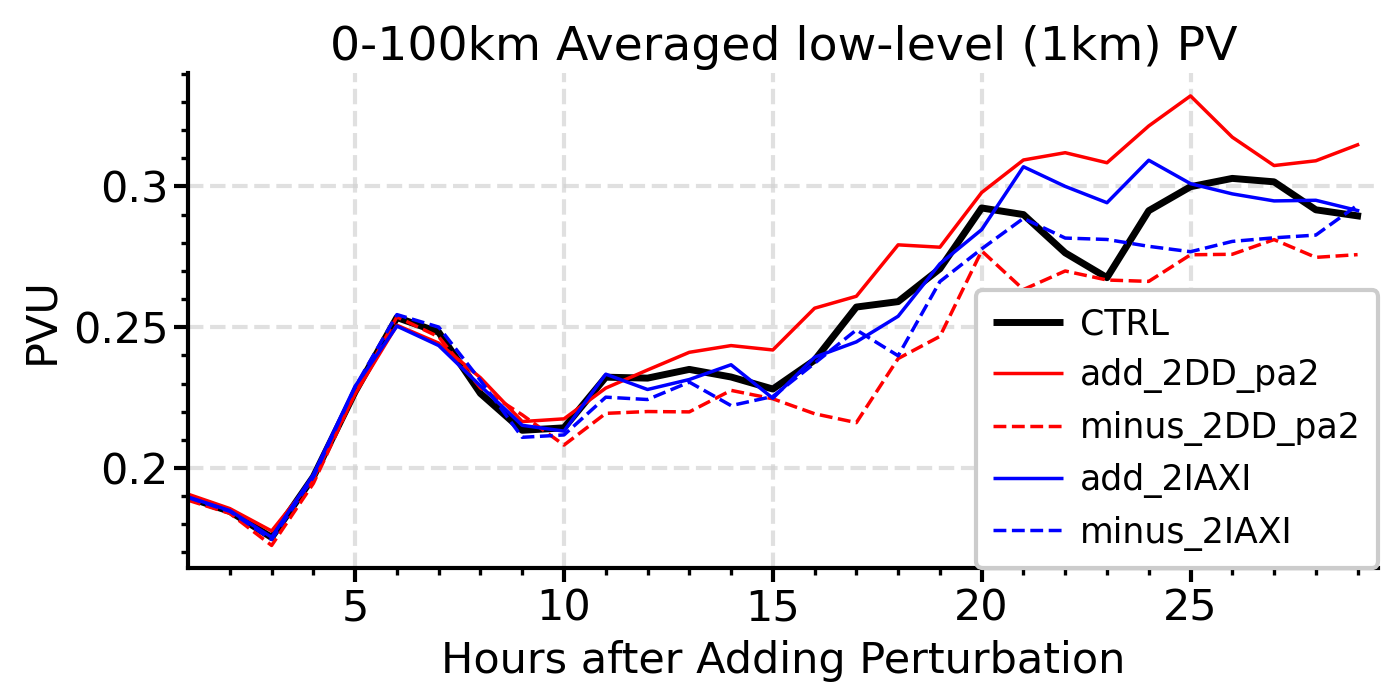

In [10]:
fig, axs = plot.subplots(ncols=1, figsize=(7,3.5), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in ctrl_avos],c='k',label='CTRL',lw=2.5)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in dd_p2f_avos],c='r',ls='-',label='add_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in mdd_p2f_avos],c='r',ls='--',label='minus_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in aiaxi2x_avos],c='b',label='add_2IAXI',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['1'] for obj in miaxi2x_avos],c='b',ls='--',label='minus_2IAXI',lw=1.25)

axs.format(xlim=(1,29.5),#ylim=(0,1),
           title='0-100km Averaged low-level (1km) PV',
           xlabel='Hours after Adding Perturbation', ylabel='PVU')
plt.legend(loc=1,ncols=1)
plt.savefig('./pics/pvo1km_memb3.png',dpi=400)
plt.show()

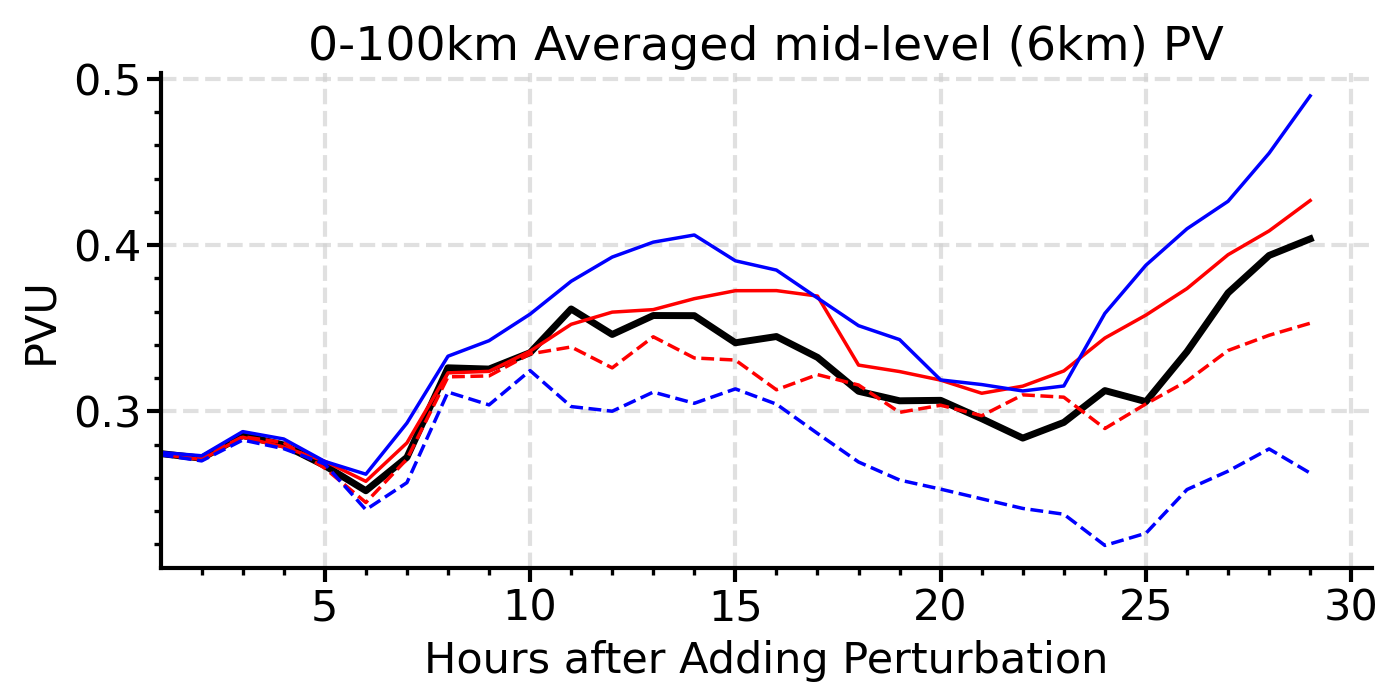

In [11]:
fig, axs = plot.subplots(ncols=1, figsize=(7,3.5), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['6'] for obj in ctrl_avos],c='k',label='CTRL',lw=2.5)
axs.plot(np.linspace(0,28,29)+1,[obj['6'] for obj in dd_p2f_avos],c='r',ls='-',label='add_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['6'] for obj in mdd_p2f_avos],c='r',ls='--',label='minus_2DD_pa2',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['6'] for obj in aiaxi2x_avos],c='b',label='add_2IAXI',lw=1.25)
axs.plot(np.linspace(0,28,29)+1,[obj['6'] for obj in miaxi2x_avos],c='b',ls='--',label='minus_2IAXI',lw=1.25)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Averaged mid-level (6km) PV',
           xlabel='Hours after Adding Perturbation', ylabel='PVU')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/pvo6km_memb3.png',dpi=400)
plt.show()

## Calculate tilt

In [30]:
def nine_point_mean(A):
    """Simple 3x3 box average with edge handling (reflect)."""
    A = np.asarray(A, dtype=float)
    pad = np.pad(A, 1, mode='reflect')
    out = (
        pad[0:-2,0:-2] + pad[0:-2,1:-1] + pad[0:-2,2:] +
        pad[1:-1,0:-2] + pad[1:-1,1:-1] + pad[1:-1,2:] +
        pad[2:,  0:-2] + pad[2:,  1:-1] + pad[2:,  2:]
    ) / 9.0
    return out

def centroid_in_window(field2d, center_ij, half_size,
                       smooth=True, top_percent=5.0,
                       dx=None, dy=None):
    """
    field2d: 2-D array [south_north, west_east] on mass grid.
    center_ij: (j0, i0) known TC center indices (south_north, west_east).
    half_size: window half-size in grid points (window is (2h+1)^2).
    smooth: apply 9-point average before thresholding.
    top_percent: keep only top p% of values (weights).
    dx, dy: optional grid spacings in meters for projected x/y output.
    """
    j0, i0 = center_ij
    j1 = int(max(j0 - half_size, 0).values)
    j2 = int(min(j0 + half_size + 1, field2d.shape[0]).values)
    i1 = int(max(i0 - half_size, 0).values)
    i2 = int(min(i0 + half_size + 1, field2d.shape[1]).values)

    W = field2d[j1:j2, i1:i2].astype(float)

    # 1) smooth (optional)
    if smooth:
        W = nine_point_mean(W)

    # 2) keep top p% (and nonnegative)
    W[np.isnan(W)] = 0.0
    W[W < 0] = 0.0
    if np.any(W):
        thr = np.percentile(W[W > 0], 100 - top_percent)
        W = np.where(W >= thr, W, 0.0)

    total = W.sum()
    if total <= 0:
        return {
            "centroid_idx": (np.nan, np.nan),
            "centroid_xy_m": (np.nan, np.nan),
            "window_bounds": (j1, j2, i1, i2),
            "weights_sum": float(total)
        }

    # 3) centroid (weighted mean) in window coordinates
    jj, ii = np.indices(W.shape)              # (row=y, col=x) starting at 0 in the window
    cj_win = (jj * W).sum() / total
    ci_win = (ii * W).sum() / total

    # convert to full-domain indices
    cj = j1 + cj_win
    ci = i1 + ci_win


    if dx is not None and dy is not None:
        # x to the east, y to the north, origin at the window's (j1,i1)
        x_m = ci_win * dx
        y_m = cj_win * dy
        xy_m = (x_m, y_m)
    else:
        xy_m = (None, None)

    return {
        "centroid_idx": (float(cj), float(ci)),   # (south_north, west_east)
        "centroid_idx_sqre":(float(cj_win), float(ci_win)),
        "centroid_xy_m": xy_m,                    # relative to window origin if dx,dy given
        "window_bounds": (j1, j2, i1, i2),
        "weights_sum": float(total),
        "W":W
    }

In [31]:
sens2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2wv1/wrfout_d02_2013-11-0*"))
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))
sens1x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_wv1/wrfout_d02_2013-11-0*"))

ctrl_centroids, sens1x_centroids, sens2x_centroids = [],[],[]
for i in tqdm(range(len(ctrl_files[:]))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    nc_sens2x = Dataset(sens2x_files[i])
    nc_sens1x = Dataset(sens1x_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Read in height
    ctrl_geopt = getvar(nc_ctrl,'height_agl')
    sens1x_geopt = getvar(nc_sens1x,'height_agl')
    sens2x_geopt = getvar(nc_sens2x,'height_agl')
    # Read in avo
    ctrl_avo = getvar(nc_ctrl, "avo")
    sens1x_avo = getvar(nc_sens1x,'avo')
    sens2x_avo = getvar(nc_sens2x,'avo')
    # Interpolate geopt to pressure level
    ctrl_ht_900 = interplevel(ctrl_geopt, ctrl_p, 900)
    sens1x_ht_900 = interplevel(sens1x_geopt, sens1x_p, 900)
    sens2x_ht_900 = interplevel(sens2x_geopt, sens2x_p, 900)

    ctrl_ht_400 = interplevel(ctrl_geopt, ctrl_p, 400)
    sens1x_ht_400 = interplevel(sens1x_geopt, sens1x_p, 400)
    sens2x_ht_400 = interplevel(sens2x_geopt, sens2x_p, 400)

    ctrl_centroids.append((centroid_in_window(ctrl_ht_900.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3), 
                           centroid_in_window(ctrl_ht_400.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3))
                         )
    sens1x_centroids.append((centroid_in_window(sens1x_ht_900.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3), 
                           centroid_in_window(sens1x_ht_400.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3))
                         )
    sens2x_centroids.append((centroid_in_window(sens2x_ht_900.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3), 
                           centroid_in_window(sens2x_ht_400.values, (iy,ix), 60,
                           smooth=True, top_percent=15.0,
                           dx=3, dy=3))
                         )

100%|██████████| 18/18 [02:21<00:00,  7.84s/it]


In [32]:
def get_tilt(centroid_obj):
    low_cen = centroid_obj[0]['centroid_xy_m']
    high_cen = centroid_obj[1]['centroid_xy_m']
    return np.sqrt((high_cen[0]-low_cen[0])**2+(high_cen[1]-low_cen[1])**2)

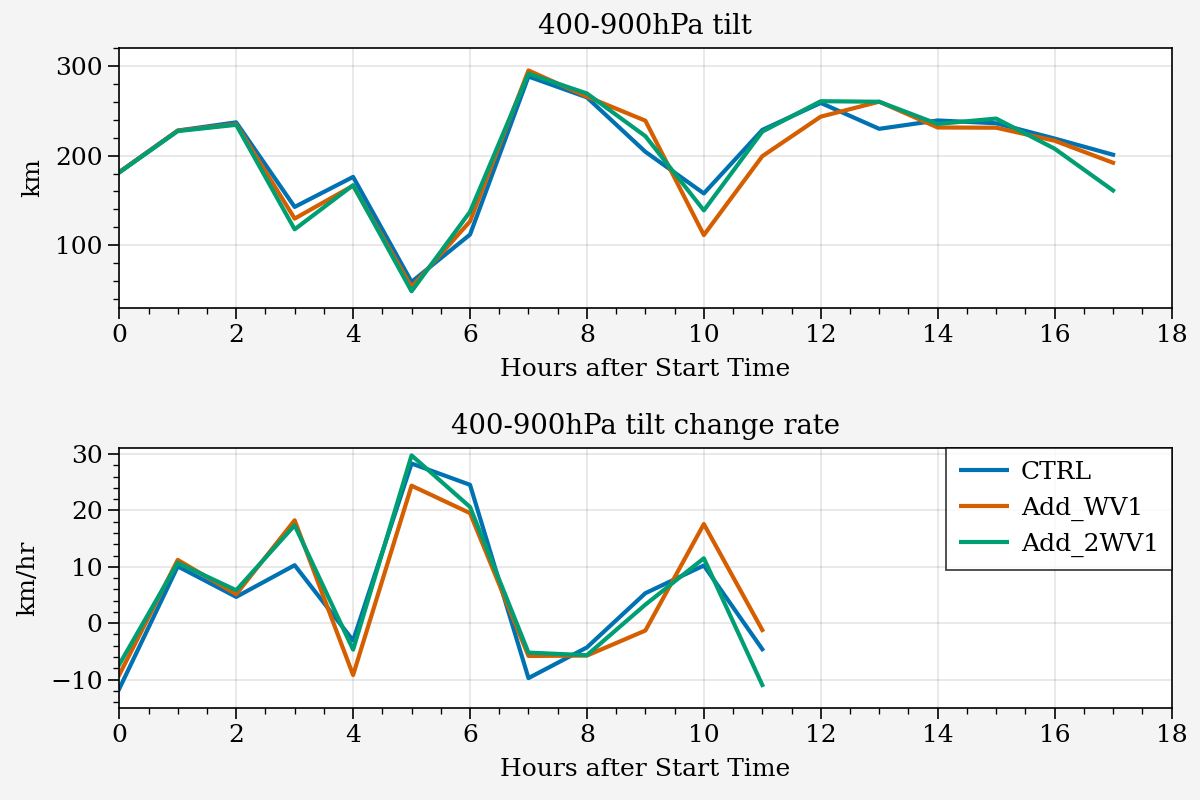

In [33]:
ctrl_tilt = np.asarray([get_tilt(ctrl_centroids[i]) for i in range(len(ctrl_centroids))])
sens1x_tilt = np.asarray([get_tilt(sens1x_centroids[i]) for i in range(len(sens1x_centroids))])
sens2x_tilt = np.asarray([get_tilt(sens2x_centroids[i]) for i in range(len(sens2x_centroids))])

fig, axs = plot.subplots(ncols=1,nrows=2, figsize=(6,4), share=False)
axs[0].plot(np.asarray([get_tilt(ctrl_centroids[i]) for i in range(len(ctrl_centroids))]),label='CTRL')
axs[0].plot(np.asarray([get_tilt(sens1x_centroids[i]) for i in range(len(sens1x_centroids))]),label='Add_WV1')
axs[0].plot(np.asarray([get_tilt(sens2x_centroids[i]) for i in range(len(sens2x_centroids))]),label='Add_2WV1')
axs[0].format(xlim=(0,18),ylim=(30,320),
           title='400-900hPa tilt',
           xlabel='Hours after Start Time', ylabel='km')

axs[1].plot((ctrl_tilt[6:]-ctrl_tilt[:-6])/6,label='CTRL')
axs[1].plot((sens1x_tilt[6:]-sens1x_tilt[:-6])/6,label='Add_WV1')
axs[1].plot((sens2x_tilt[6:]-sens2x_tilt[:-6])/6,label='Add_2WV1')
axs[1].format(xlim=(0,18),ylim=(-15,31),
           title='400-900hPa tilt change rate',
           xlabel='Hours after Start Time', ylabel='km/hr')
plt.legend(loc=1,ncols=1)
plt.savefig('./figs/tiltevol.png',dpi=400)
plt.show()
